In [1]:
!pip install rasterio

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import numpy as np
import rasterio
from scipy import stats
from skimage.feature import local_binary_pattern
import pywt

In [3]:
def extract_features(image_path):
    with rasterio.open(image_path) as src:
        image = src.read().astype(np.float32) / 10000 
    
    features = {}
    def calculate_ratio(band1, band2):
        return np.divide(band1, band2, where=band2!=0)

    # Ratio and statistical features
    features['ratio_band_1_8_mean_max_ratio'] = np.mean(calculate_ratio(image[0], image[7])) / np.max(calculate_ratio(image[0], image[7]))
    features['min_max_ratio_3'] = np.min(image[2]) / np.max(image[2])
    features['ratio_band_1_3_2_std'] = (np.std(calculate_ratio(image[0], image[2])) + np.std(calculate_ratio(image[0], image[1]))) / 2
    features['ratio_band_3_5_1_3_diff'] = np.mean(calculate_ratio(image[2], image[4])) - np.std(calculate_ratio(image[0], image[2]))
    features['ratio_band_2_4_1_2_diff'] = np.max(calculate_ratio(image[1], image[3])) - np.min(calculate_ratio(image[0], image[1]))
    features['ratio_band_2_3_mean_std_ratio'] = np.mean(calculate_ratio(image[1], image[2])) / np.std(calculate_ratio(image[1], image[2]))
    features['ratio_band_4_10_min_log'] = np.log1p(np.min(calculate_ratio(image[3], image[9])))
    features['ratio_band_1_8_max_mean_diff'] = np.max(calculate_ratio(image[0], image[7])) - np.mean(calculate_ratio(image[0], image[7]))
    features['ratio_band_3_5_1_3_std'] = np.std([calculate_ratio(image[2], image[4]), calculate_ratio(image[0], image[2])])
    features['band_1_2_3_4_correlation'] = np.corrcoef([image[0].flatten(), image[1].flatten(), image[2].flatten(), image[3].flatten()])[0,1]
    features['ratio_band_12_13_std'] = np.std(calculate_ratio(image[11], image[12]))
    features['band_6_13_std_ratio'] = np.std(image[5]) / np.std(image[12])
    features['ratio_band_1_7_13_max_std_ratio'] = np.max(calculate_ratio(image[0], image[6])) / np.std(calculate_ratio(image[0], image[12]))
    features['band_3_10_min_mean_diff'] = np.mean(image[2]) - np.min(image[9])
    features['ratio_band_1_9_std_min_diff'] = np.std(calculate_ratio(image[0], image[8])) - np.min(calculate_ratio(image[0], image[8]))
    features['ratio_band_3_5_mean'] = np.mean(calculate_ratio(image[2], image[4]))
    features['ratio_band_2_5_8_11_mean'] = np.mean([calculate_ratio(image[1], image[4]), calculate_ratio(image[1], image[7]), calculate_ratio(image[1], image[10])])

    # Min and pool features
    features['band_1_pool_1_min'] = np.min(image[0])
    features['band_2_pool_1_min'] = np.min(image[1])
    features['band_3_pool_1_min'] = np.min(image[2])
    features['band_7_pool_1_min'] = np.min(image[6])

    # LBP feature
    lbp = local_binary_pattern(image [0], 8, 1, method='uniform')
    features['band_1_window_3_lbp_entropy'] = stats.entropy(np.histogram(lbp, bins=256)[0])

    # Wavelet features
    coeffs = pywt.wavedec2(image[0], 'haar', level=3)
    cA3, (cH3, cV3, cD3), (cH2, cV2, cD2), (cH1, cV1, cD1) = coeffs
    features['band_1_wavelet_haar_cD3_min'] = np.min(cD3)

    coeffs = pywt.wavedec2(image[1], 'haar', level=3)
    cA3, (cH3, cV3, cD3), (cH2, cV2, cD2), (cH1, cV1, cD1) = coeffs
    features['band_2_wavelet_haar_cH1_max'] = np.max(cH1)
    features['band_2_wavelet_haar_cD2_max'] = np.max(cD2)
    features['band_2_wavelet_haar_cD3_min'] = np.min(cD3)

    coeffs = pywt.wavedec2(image[2], 'haar', level=3)
    cA3, (cH3, cV3, cD3), (cH2, cV2, cD2), (cH1, cV1, cD1) = coeffs
    features['band_3_wavelet_haar_cH1_max'] = np.max(cH1)

    coeffs = pywt.wavedec2(image[3], 'haar', level=3)
    cA3, (cH3, cV3, cD3), (cH2, cV2, cD2), (cH1, cV1, cD1) = coeffs
    features['band_4_wavelet_haar_cD1_std'] = np.std(cD1)

    coeffs = pywt.wavedec2(image[5], 'haar', level=3)
    cA3, (cH3, cV3, cD3), (cH2, cV2, cD2), (cH1, cV1, cD1) = coeffs
    features['band_6_wavelet_haar_cH2_max'] = np.max(cH2)

    coeffs = pywt.wavedec2(image[6], 'haar', level=3)
    cA3, (cH3, cV3, cD3), (cH2, cV2, cD2), (cH1, cV1, cD1) = coeffs
    features['band_7_wavelet_haar_cV2_max'] = np.max(cV2)

    coeffs = pywt.wavedec2(image[11], 'haar', level=3)
    cA3, (cH3, cV3, cD3), (cH2, cV2, cD2), (cH1, cV1, cD1) = coeffs
    features['band_12_wavelet_haar_cV1_std'] = np.std(cV1)

    coeffs = pywt.wavedec2(image[12], 'haar', level=3)
    cA3, (cH3, cV3, cD3), (cH2, cV2, cD2), (cH1, cV1, cD1) = coeffs
    features['band_13_wavelet_haar_cV1_min'] = np.min(cV1)
    features['band_13_wavelet_haar_cD1_std'] = np.std(cD1)
    features['band_13_wavelet_haar_cV2_std'] = np.std(cV2)
    features['band_13_wavelet_haar_cD2_std'] = np.std(cD2)
    features['band_13_wavelet_haar_cD3_std'] = np.std(cD3)

    feature_values = np.array(list(features.values()))
    feature_values = np.nan_to_num(feature_values, nan=0.0, posinf=0.0, neginf=0.0)
    
    feature_names = list(features.keys())
    return feature_values,feature_names

In [4]:
import os
import csv
import numpy as np
import rasterio


def process_csv(csv_file, base_path, save_path):
    all_features = []
    all_feature_names = []
    all_labels = []

    with open(csv_file, mode='r') as file:
        reader = csv.reader(file)
        for row in reader:
            file_name, _, label = row
            image_path = os.path.join(base_path, file_name)

            feature_values, feature_names = extract_features(image_path)

            all_features.append(feature_values)
            all_feature_names = feature_names  
            all_labels.append(float(label))  

    features_array = np.array(all_features)
    labels_array = np.array(all_labels)

    np.savez(save_path, features=features_array, feature_names=feature_names, labels=labels_array)
    print(f"Features and labels saved to {save_path}")


csv_file = "/home/coeai/Desktop/MM/train_answer.csv" 
base_path = "/home/coeai/Desktop/MM/train_images"  
save_path = "extracted_features_with_labels.npz" 

process_csv(csv_file, base_path, save_path)


/home/coeai/.local/lib/python3.10/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/tmp/ipykernel_7273/1590598485.py:16: RuntimeWarning: invalid value encountered in log1p
  features['ratio_band_4_10_min_log'] = np.log1p(np.min(calculate_ratio(image[3], image[9])))


Features and labels saved to extracted_features_with_labels.npz


In [5]:
import os
import numpy as np
import rasterio
import scipy

def process_folder(folder_path, save_path):
    feature_list = []
    file_names = []

    for filename in os.listdir(folder_path):
        if filename.endswith(".tif"):
            filepath = os.path.join(folder_path, filename)
            feats, feat_names = extract_features(filepath)
            feature_list.append(feats)
            file_names.append(filename)

    all_feature_names = feat_names
    all_features = np.array(feature_list)

    np.savez_compressed(save_path,features=all_features,file_names=file_names,feature_names=all_feature_names)


    print(f"Saved features to {save_path}")
    print(f"Number of images processed: {len(file_names)}")
    print(f"Number of features per image: {len(all_feature_names)}")
    return all_features, file_names 


def load_features(save_path):
    loaded_data = np.load(save_path, allow_pickle=True)
    features = loaded_data['features']
    feature_names = loaded_data['feature_names']
    file_names = loaded_data['file_names']
    return features, feature_names, file_names

base_path = "/home/coeai/Desktop/MM/test_images" 
save_path = "extracted_test_features.npz" 

process_folder(base_path, save_path)

/tmp/ipykernel_7273/1590598485.py:16: RuntimeWarning: invalid value encountered in log1p
  features['ratio_band_4_10_min_log'] = np.log1p(np.min(calculate_ratio(image[3], image[9])))


Saved features to extracted_test_features.npz
Number of images processed: 1489
Number of features per image: 36


(array([[2.75225013e-01, 1.32471323e-01, 2.74438292e-01, ...,
         5.66723293e-06, 3.64148605e-06, 6.74831654e-06],
        [6.31860733e-01, 2.72510916e-01, 9.84279066e-02, ...,
         6.23285359e-06, 3.31417709e-06, 6.85556643e-06],
        [2.18775183e-01, 1.30644351e-01, 1.91904336e-01, ...,
         4.64803361e-06, 2.75353432e-06, 7.43339706e-06],
        ...,
        [3.05504650e-01, 1.80512339e-01, 1.83789745e-01, ...,
         5.25063660e-06, 3.16096339e-06, 6.30098066e-06],
        [5.34061909e-01, 2.83087283e-01, 1.17300853e-01, ...,
         5.66067411e-06, 3.05773665e-06, 6.38068786e-06],
        [2.59183645e-01, 1.31327957e-01, 2.07574993e-01, ...,
         5.42298858e-06, 3.39053031e-06, 6.45588261e-06]]),
 ['test_1018.tif',
  'test_732.tif',
  'test_1403.tif',
  'test_978.tif',
  'test_184.tif',
  'test_1389.tif',
  'test_695.tif',
  'test_61.tif',
  'test_1074.tif',
  'test_713.tif',
  'test_704.tif',
  'test_1319.tif',
  'test_475.tif',
  'test_398.tif',
  'test_6

In [6]:
def load_features(save_path):
    loaded_data = np.load(save_path, allow_pickle=True)
    features = loaded_data['features']
    feature_names = loaded_data['feature_names']
    file_names = loaded_data['file_names']
    return features, feature_names, file_names

# Example usage to load the saved test features
features, feature_names, file_names = load_features('extracted_test_features.npz')

print("Feature Names:", feature_names)
print("Shape of Features:", features.shape)
print("File Names:", file_names[:5])

Feature Names: ['ratio_band_1_8_mean_max_ratio' 'min_max_ratio_3' 'ratio_band_1_3_2_std'
 'ratio_band_3_5_1_3_diff' 'ratio_band_2_4_1_2_diff'
 'ratio_band_2_3_mean_std_ratio' 'ratio_band_4_10_min_log'
 'ratio_band_1_8_max_mean_diff' 'ratio_band_3_5_1_3_std'
 'band_1_2_3_4_correlation' 'ratio_band_12_13_std' 'band_6_13_std_ratio'
 'ratio_band_1_7_13_max_std_ratio' 'band_3_10_min_mean_diff'
 'ratio_band_1_9_std_min_diff' 'ratio_band_3_5_mean'
 'ratio_band_2_5_8_11_mean' 'band_1_pool_1_min' 'band_2_pool_1_min'
 'band_3_pool_1_min' 'band_7_pool_1_min' 'band_1_window_3_lbp_entropy'
 'band_1_wavelet_haar_cD3_min' 'band_2_wavelet_haar_cH1_max'
 'band_2_wavelet_haar_cD2_max' 'band_2_wavelet_haar_cD3_min'
 'band_3_wavelet_haar_cH1_max' 'band_4_wavelet_haar_cD1_std'
 'band_6_wavelet_haar_cH2_max' 'band_7_wavelet_haar_cV2_max'
 'band_12_wavelet_haar_cV1_std' 'band_13_wavelet_haar_cV1_min'
 'band_13_wavelet_haar_cD1_std' 'band_13_wavelet_haar_cV2_std'
 'band_13_wavelet_haar_cD2_std' 'band_13_wavel

In [7]:
print(type(features))
print(features.shape)

<class 'numpy.ndarray'>
(1489, 36)


In [8]:
%whos

Variable               Type        Data/Info
--------------------------------------------
base_path              str         /home/coeai/Desktop/MM/test_images
csv                    module      <module 'csv' from '/usr/lib/python3.10/csv.py'>
csv_file               str         /home/coeai/Desktop/MM/train_answer.csv
extract_features       function    <function extract_features at 0x7657213944c0>
feature_names          ndarray     36: 36 elems, type `<U31`, 4464 bytes
features               ndarray     1489x36: 53604 elems, type `float64`, 428832 bytes (418.78125 kb)
file_names             ndarray     1489: 1489 elems, type `<U13`, 77428 bytes
load_features          function    <function load_features at 0x7656d6313370>
local_binary_pattern   function    <function local_binary_pattern at 0x7656d8d5ac20>
np                     module      <module 'numpy' from '/ho<...>kages/numpy/__init__.py'>
os                     module      <module 'os' from '/usr/lib/python3.10/os.py'>
process_csv 

In [9]:
import pandas as pd

# Load AOD labels
labels_df = pd.read_csv(csv_file)

# View the columns to identify the target
print(labels_df.columns)

Index(['train_1.tif', 'Camaguey', '0.04161685225788304'], dtype='object')


In [10]:
import pandas as pd

# Rerun just in case
labels_df = pd.read_csv(csv_file, header=None, names=["filename", "location", "AOD"])

# Check structure
print("CSV Columns:", labels_df.columns.tolist())
print("First few rows:\n", labels_df.head())

CSV Columns: ['filename', 'location', 'AOD']
First few rows:
       filename          location       AOD
0  train_1.tif          Camaguey  0.041617
1  train_2.tif         Pontianak  0.187255
2  train_3.tif  Hong_Kong_Sheung  0.214568
3  train_4.tif      Beijing-CAMS  0.084528
4  train_5.tif       ATHENS_NTUA  0.085251


In [11]:
# Reload and clean CSV
labels_df = pd.read_csv(csv_file, header=None, names=["filename", "location", "AOD"])
labels_df["filename"] = labels_df["filename"].str.strip()

# Clean the filenames from the image processing output
file_names = np.char.strip(file_names)

In [12]:
file_names_set = set(np.char.strip(file_names))
csv_names_set = set(labels_df["filename"].str.strip())

missing_in_csv = file_names_set - csv_names_set

print(f"\nFilenames in features but NOT in CSV: {len(missing_in_csv)}")
print(list(missing_in_csv)[:10])  # show first 10


Filenames in features but NOT in CSV: 1489
['test_15.tif', 'test_883.tif', 'test_1105.tif', 'test_1365.tif', 'test_1123.tif', 'test_1299.tif', 'test_544.tif', 'test_1214.tif', 'test_273.tif', 'test_183.tif']


In [13]:
train_base_path = "/home/coeai/Desktop/MM/train_images"
train_save_path = "extracted_train_features.npz"

features, file_names = process_folder(train_base_path, train_save_path)


/home/coeai/.local/lib/python3.10/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/tmp/ipykernel_7273/1590598485.py:16: RuntimeWarning: invalid value encountered in log1p
  features['ratio_band_4_10_min_log'] = np.log1p(np.min(calculate_ratio(image[3], image[9])))


Saved features to extracted_train_features.npz
Number of images processed: 4465
Number of features per image: 36


In [14]:
features, feature_names, file_names = load_features(train_save_path)

In [15]:
labels_df = pd.read_csv(csv_file, header=None, names=["filename", "location", "AOD"])
labels_df["filename"] = labels_df["filename"].str.strip()
file_names = np.char.strip(file_names)

# Filter and align labels to the feature filenames
matched_labels = labels_df[labels_df["filename"].isin(file_names)]
matched_labels = matched_labels.set_index("filename").loc[file_names]

y = matched_labels["AOD"].astype(float).values

In [16]:
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np

# 17-fold cross-validation
kf = KFold(n_splits=17, shuffle=True, random_state=42)

rmse_scores = []
fold = 1

for train_index, val_index in kf.split(features):
    X_train, X_val = features[train_index], features[val_index]
    y_train, y_val = y[train_index], y[val_index]

    # Define model
    model = CatBoostRegressor(
        iterations=500,
        learning_rate=0.1,
        depth=6,
        loss_function='RMSE',
        verbose=0,
        random_seed=42
    )

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_val)

    # Evaluate
    rmse = mean_squared_error(y_val, y_pred, squared=False)
    rmse_scores.append(rmse)

    print(f"Fold {fold} RMSE: {rmse:.4f}")
    fold += 1

# Final summary
print("\nDone with 17-fold CV")
print(f"Average RMSE: {np.mean(rmse_scores):.4f}")
print(f"Standard Deviation: {np.std(rmse_scores):.4f}")

/home/coeai/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Fold 1 RMSE: 0.0579


/home/coeai/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Fold 2 RMSE: 0.0630


/home/coeai/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Fold 3 RMSE: 0.1064


/home/coeai/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Fold 4 RMSE: 0.0699


/home/coeai/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Fold 5 RMSE: 0.0511


/home/coeai/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Fold 6 RMSE: 0.0676


/home/coeai/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Fold 7 RMSE: 0.0430


/home/coeai/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Fold 8 RMSE: 0.0438


/home/coeai/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Fold 9 RMSE: 0.0677


/home/coeai/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Fold 10 RMSE: 0.0759


/home/coeai/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Fold 11 RMSE: 0.1041


/home/coeai/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Fold 12 RMSE: 0.0447


/home/coeai/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Fold 13 RMSE: 0.0526


/home/coeai/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Fold 14 RMSE: 0.0466


/home/coeai/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Fold 15 RMSE: 0.0454


/home/coeai/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Fold 16 RMSE: 0.0621
Fold 17 RMSE: 0.1297

Done with 17-fold CV
Average RMSE: 0.0666
Standard Deviation: 0.0243


/home/coeai/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [17]:
def load_features(save_path):
    loaded_data = np.load(save_path, allow_pickle=True)
    features = loaded_data['features']
    feature_names = loaded_data['feature_names']
    file_names = loaded_data['file_names']
    return features, feature_names, file_names

X_test, feature_names_test, test_file_names = load_features('extracted_test_features.npz')

In [18]:
X = features
y = matched_labels["AOD"].astype(float).values

from catboost import CatBoostRegressor

final_model = CatBoostRegressor(verbose=0, random_state=42)
final_model.fit(X, y)

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Scale the full feature set
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train final model on all data
final_model = CatBoostRegressor(verbose=0, random_state=42)
final_model.fit(X_scaled, y)
y_pred_full = final_model.predict(X_scaled)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y, y_pred_full))
mae = mean_absolute_error(y, y_pred_full)
r2 = r2_score(y, y_pred_full)

print("Final Model Performance on Full Training Set:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

Final Model Performance on Full Training Set:
RMSE: 0.0193
MAE: 0.0147
R²: 0.9926


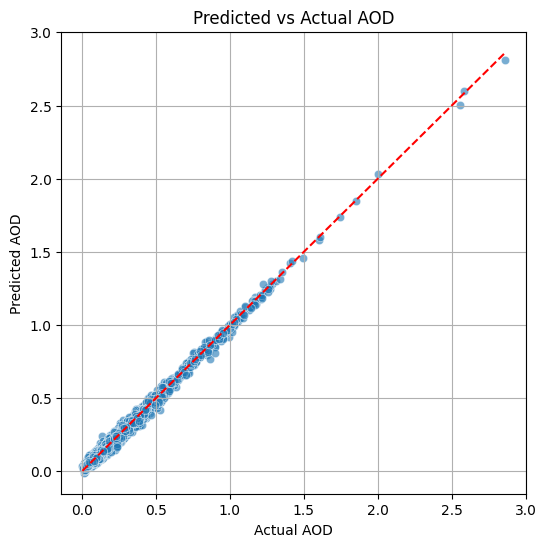

In [20]:
# Scatter Plot: Predicted vs Actual
plt.figure(figsize=(6,6))
sns.scatterplot(x=y, y=y_pred_full, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual AOD")
plt.ylabel("Predicted AOD")
plt.title("Predicted vs Actual AOD")
plt.grid(True)
plt.show()

In [21]:
# Residuals
residuals = y - y_pred_full

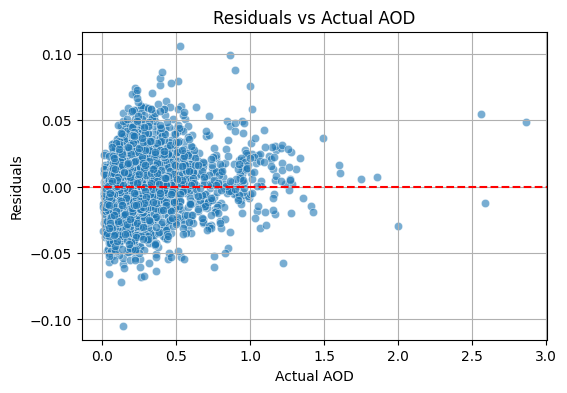

In [22]:
# Residual Plot
plt.figure(figsize=(6,4))
sns.scatterplot(x=y, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Actual AOD")
plt.ylabel("Residuals")
plt.title("Residuals vs Actual AOD")
plt.grid(True)
plt.show()

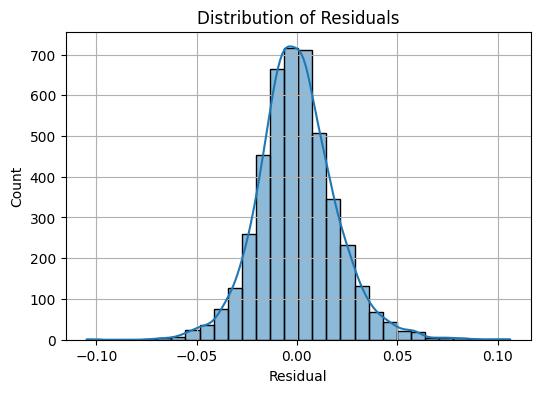

In [23]:
# Histogram of Residuals
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel("Residual")
plt.title("Distribution of Residuals")
plt.grid(True)
plt.show()

In [24]:
import os
from glob import glob

test_dir = "/home/coeai/Desktop/MM/test_images"  
image_paths_test = sorted(glob(os.path.join(test_dir, "*.tif")))

In [25]:
features_test = [extract_features(path)[0] for path in image_paths_test]
features_test = pd.DataFrame(features_test)

/home/coeai/.local/lib/python3.10/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/tmp/ipykernel_7273/1590598485.py:16: RuntimeWarning: invalid value encountered in log1p
  features['ratio_band_4_10_min_log'] = np.log1p(np.min(calculate_ratio(image[3], image[9])))


In [26]:
print(features_test.shape)
print(features_test.head())

(1489, 36)
         0         1         2         3         4          5         6   \
0  0.405749  0.055968  0.185566  0.652627  1.597233  20.794189  0.418087   
1  0.327807  0.136984  0.195978  0.686806  1.778808  20.827208  0.289142   
2  0.235674  0.109700  0.175575  0.737897  1.947718  18.074289  0.371868   
3  0.395444  0.311873  0.104147  0.744307  1.155722  22.382723  0.695089   
4  0.165755  0.098824  0.259011  0.599357  2.494120   9.267140  0.212845   

         7         8         9   ...        26        27        28        29  \
0  1.195586  0.230882  0.679495  ...  0.000059  0.000003  0.000031  0.000024   
1  1.670482  0.222734  0.702211  ...  0.000017  0.000003  0.000033  0.000037   
2  2.422639  0.259402  0.861092  ...  0.000015  0.000001  0.000032  0.000028   
3  1.178479  0.132817  0.699005  ...  0.000009  0.000002  0.000020  0.000024   
4  4.465198  0.423732  0.795523  ...  0.000027  0.000001  0.000029  0.000027   

         30        31            32        33      

In [27]:
X_test_scaled = scaler.transform(features_test)
y_pred_test = final_model.predict(X_test_scaled)

In [28]:
print("Predictions on test set (first 10):")
print(y_pred_test[:10])

Predictions on test set (first 10):
[0.07390628 0.08100514 0.13218707 0.31152844 0.03931201 0.06945496
 0.11411151 0.27085073 0.06328168 0.1852148 ]


In [29]:
# Combine filenames and predictions
import pandas as pd

filenames_test = [os.path.basename(path) for path in image_paths_test]

results_df = pd.DataFrame({
    "filename": filenames_test,
    "predicted_AOD": y_pred_test
})

# Save to CSV
results_df.to_csv("aod_predictions_test_set.csv", index=False)

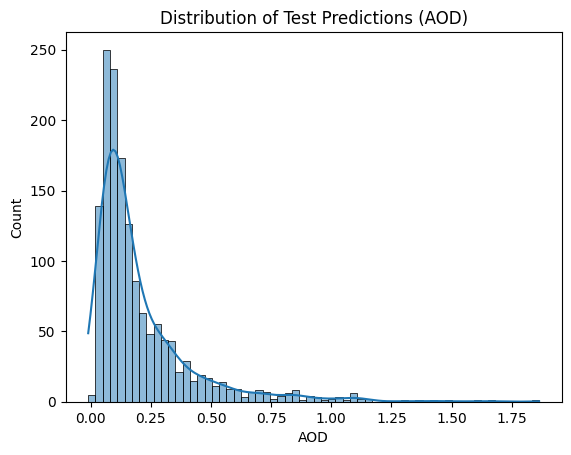

In [30]:
import matplotlib.pyplot as plt

sns.histplot(y_pred_test, kde=True)
plt.title("Distribution of Test Predictions (AOD)")
plt.xlabel("AOD")
plt.ylabel("Count")
plt.show()

In [31]:
!pip install shap
import shap

# SHAP explainer
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_scaled)

Defaulting to user installation because normal site-packages is not writeable


/home/coeai/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


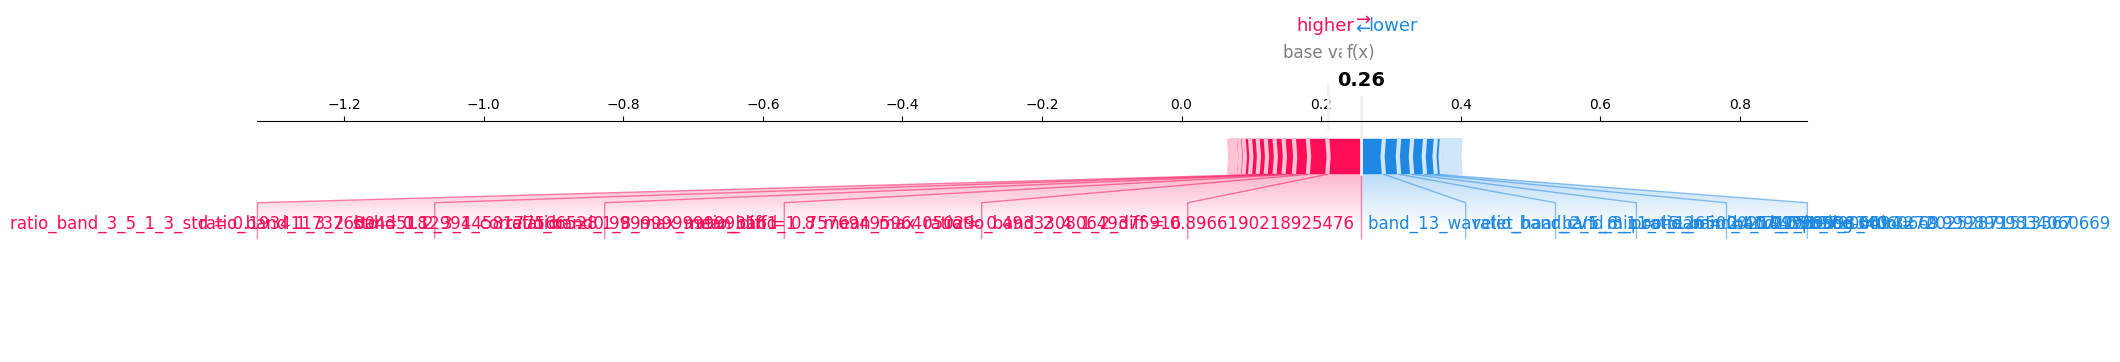

In [32]:
# Re-create DataFrame from NumPy array
X_df = pd.DataFrame(X, columns=feature_names)

# Force Plot
sample_index = 0
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_index],
    X_df.iloc[sample_index],
    matplotlib=True
)

<Figure size 640x480 with 0 Axes>

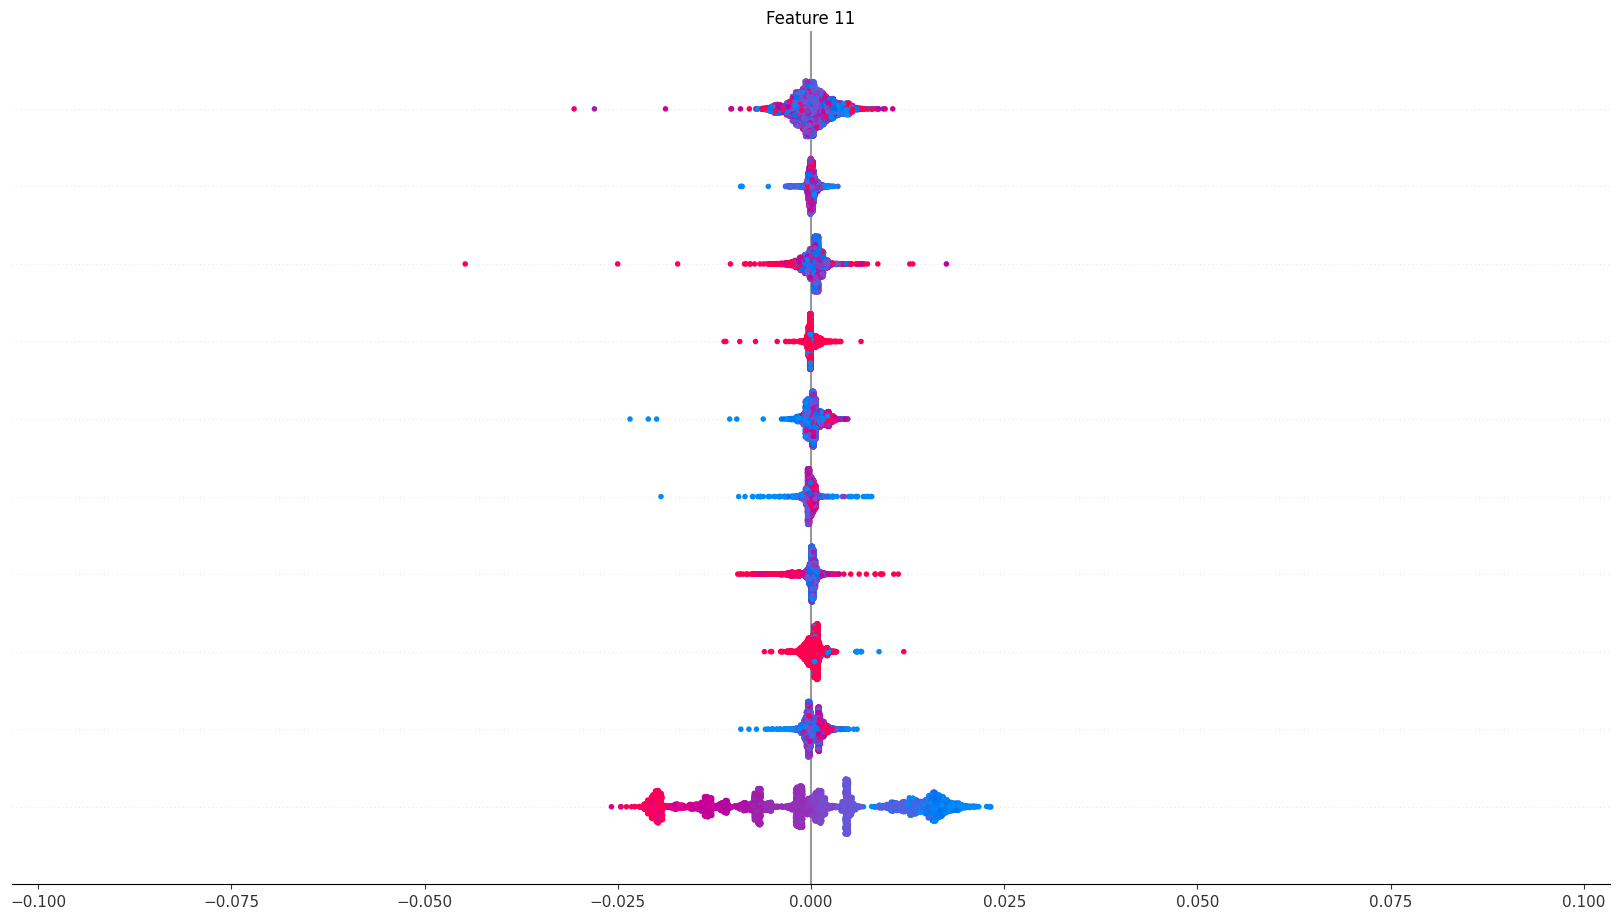

In [33]:
# SHAP Interaction Values
interaction_values = explainer.shap_interaction_values(X_scaled)

# SHAP Summary Interaction Plot
shap.summary_plot(interaction_values, X, plot_type="dot", max_display=10)

In [34]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'iterations': [100, 200],
    'l2_leaf_reg': [1, 3, 5]
}

# CatBoost with GridSearchCV
cb = CatBoostRegressor(verbose=0, random_state=42)
grid_search = GridSearchCV(cb, param_grid, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1)

# Fit on full scaled data
grid_search.fit(X_scaled, y)

print("Best Parameters:", grid_search.best_params_)
print("Best RMSE (CV):", -grid_search.best_score_)

# Final model with best parameters
best_model = grid_search.best_estimator_

/home/coeai/.local/lib/python3.10/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Parameters: {'depth': 8, 'iterations': 200, 'l2_leaf_reg': 3, 'learning_rate': 0.1}
Best RMSE (CV): 0.07092752974206684


In [35]:
X_df = pd.DataFrame(X, columns=feature_names)

# SHAP-based Feature Importance
shap_importance = np.abs(shap_values).mean(axis=0)
shap_importance_df = pd.DataFrame({
    'feature': X_df.columns,
    'importance': shap_importance
}).sort_values(by='importance', ascending=False)

# Drop features below SHAP importance threshold
shap_threshold = 0.01
selected_features = shap_importance_df[shap_importance_df['importance'] >= shap_threshold]['feature'].tolist()

print(f"Selected {len(selected_features)} features out of {X.shape[1]}")
shap_importance_df.head(10)

Selected 8 features out of 36


,feature,importance
3,ratio_band_3_5_1_3_diff,0.040272
2,ratio_band_1_3_2_std,0.020136
0,ratio_band_1_8_mean_max_ratio,0.019022
19,band_3_pool_1_min,0.018447
7,ratio_band_1_8_max_mean_diff,0.018119
4,ratio_band_2_4_1_2_diff,0.018087
6,ratio_band_4_10_min_log,0.011420
18,band_2_pool_1_min,0.010822
8,ratio_band_3_5_1_3_std,0.009965
11,band_6_13_std_ratio,0.008698


In [36]:
# Subset X using the selected important features
X_shap_filtered = pd.DataFrame(X, columns=feature_names)[selected_features]

In [37]:
# Correlation filtering
corr_matrix = X_shap_filtered.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Drop features with high correlation
correlation_threshold = 0.9
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > correlation_threshold)]

X_filtered = X_shap_filtered.drop(columns=to_drop)

print(f"Features dropped due to high correlation: {len(to_drop)}")
print(f"Final selected features: {X_filtered.shape[1]}")

# Rescale filtered features
scaler = StandardScaler()
X_filtered_scaled = scaler.fit_transform(X_filtered)

Features dropped due to high correlation: 5
Final selected features: 3


In [38]:
# Rescale filtered features
scaler = StandardScaler()
X_filtered_scaled = scaler.fit_transform(X_filtered)

In [39]:
best_params = {
    'depth': 8,
    'iterations': 200,
    'l2_leaf_reg': 3,
    'learning_rate': 0.1
}

final_model_filtered = CatBoostRegressor(**best_params, verbose=0, random_state=42)
final_model_filtered.fit(X_filtered_scaled, y)

y_pred_filtered = final_model_filtered.predict(X_filtered_scaled)
rmse_filtered = np.sqrt(mean_squared_error(y, y_pred_filtered))
mae_filtered = mean_absolute_error(y, y_pred_filtered)
r2_filtered = r2_score(y, y_pred_filtered)

print("Filtered Model Performance:")
print(f"RMSE: {rmse_filtered:.8f}")
print(f"MAE: {mae_filtered:.8f}")
print(f"R²: {r2_filtered:.8f}")

Filtered Model Performance:
RMSE: 0.07086852
MAE: 0.04773672
R²: 0.90008302


In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
import shap
import numpy as np
import pandas as pd

# Recalculate SHAP and Interaction Values
explainer_filtered = shap.TreeExplainer(final_model_filtered)
shap_values_filtered = explainer_filtered.shap_values(X_filtered_scaled)
interaction_values = explainer_filtered.shap_interaction_values(X_filtered_scaled)

# SHAP Feature Importance
shap_importance = np.abs(shap_values_filtered).mean(axis=0)
shap_importance_df = pd.DataFrame({
    'feature': X_filtered.columns,
    'importance': shap_importance
}).sort_values(by='importance', ascending=False)

# Top 3 most important features for PDPs with ICE
top_features = shap_importance_df['feature'].tolist()[:3]

# Identify Strongest Interacting Pairs
# Upper triangle of interaction matrix, excluding self-interactions
interaction_matrix = np.abs(interaction_values).mean(axis=0)
np.fill_diagonal(interaction_matrix, 0)  # remove self-interactions
top_pair_indices = np.dstack(np.unravel_index(np.argsort(interaction_matrix.ravel())[::-1], interaction_matrix.shape))[0]

# Keep only unique top 2 pairs
unique_pairs = []
added = set()
for i, j in top_pair_indices:
    if (i, j) not in added and (j, i) not in added:
        unique_pairs.append((i, j))
        added.add((i, j))
    if len(unique_pairs) == 2:
        break

PDPs with ICE Lines


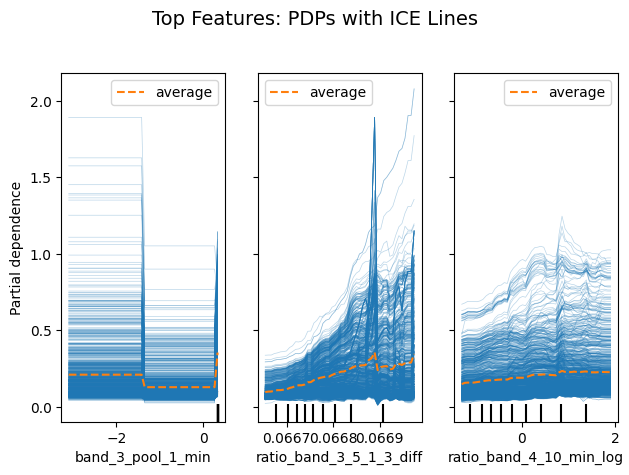

In [54]:
# PDPs with ICE Lines
print("PDPs with ICE Lines")
PartialDependenceDisplay.from_estimator(
    final_model_filtered,
    X_filtered_scaled,
    features=top_features,
    feature_names=X_filtered.columns,
    kind='both',
    grid_resolution=50,
    n_cols=3
)
plt.suptitle("Top Features: PDPs with ICE Lines", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

2D Interaction PDPs from SHAP Interaction Importance


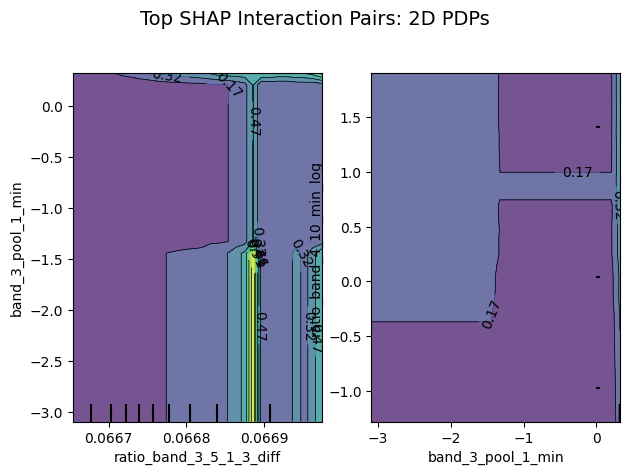

In [55]:
# 2D PDPs for SHAP Interaction Pairs
print("2D Interaction PDPs from SHAP Interaction Importance")
PartialDependenceDisplay.from_estimator(
    final_model_filtered,
    X_filtered_scaled,
    features=unique_pairs,
    feature_names=X_filtered.columns,
    kind='average',
    grid_resolution=30
)
plt.suptitle("Top SHAP Interaction Pairs: 2D PDPs", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [56]:
!pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable


In [57]:
from sklearn.ensemble import StackingRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define base learners (already tuned or use default for now)
base_learners = [
    ('catboost', CatBoostRegressor(**best_params, verbose=0, random_state=42)),
    ('xgboost', XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42)),
    ('lightgbm', LGBMRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42))
]

# Gradient Boosting Regressor as meta-learner
meta_learner = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Create stacked ensemble
stacked_ensemble_final = StackingRegressor(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    n_jobs=-1
)

# Fit ensemble
stacked_ensemble_final.fit(X_filtered_scaled, y)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000188 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 4465, number of used features: 3
[LightGBM] [Info] Start training from score 0.209845
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

StackingRegressor(cv=5,
                  estimators=[('catboost',
                               <catboost.core.CatBoostRegressor object at 0x7656f45bf100>),
                              ('xgboost',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=None,...
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=6,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=42, ...)),
                              ('lightgbm',
                               LGBMRegressor(max_depth=6, n_estimators=200,
                                             random_state=42))],
                  final_estimator=GradientBoostingRegressor(random_state=42),
                  n_jobs=-1)

In [58]:
# Predict and evaluate
y_pred_ensemble_final = stacked_ensemble_final.predict(X_filtered_scaled)

rmse_final = np.sqrt(mean_squared_error(y, y_pred_ensemble_final))
mae_final = mean_absolute_error(y, y_pred_ensemble_final)
r2_final = r2_score(y, y_pred_ensemble_final)

print("Final Stacked Ensemble (with GBDT meta-learner) Performance:")
print(f"RMSE: {rmse_final:.4f}")
print(f"MAE: {mae_final:.4f}")
print(f"R²: {r2_final:.4f}")

Final Stacked Ensemble (with GBDT meta-learner) Performance:
RMSE: 0.0887
MAE: 0.0494
R²: 0.8434


In [59]:
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression

# Base models
catboost_model = CatBoostRegressor(**best_params, verbose=0, random_state=42)
xgboost_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=8, random_state=42)
lightgbm_model = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.1, max_depth=8, random_state=42)

# Meta model
meta_model = LinearRegression()

# Stacking ensemble
stacked_model = StackingRegressor(
    estimators=[
        ('catboost', catboost_model),
        ('xgboost', xgboost_model),
        ('lightgbm', lightgbm_model)
    ],
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

In [60]:
stacked_model.fit(X_filtered_scaled, y)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000270 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 4465, number of used features: 3
[LightGBM] [Info] Start training from score 0.209845
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

StackingRegressor(cv=5,
                  estimators=[('catboost',
                               <catboost.core.CatBoostRegressor object at 0x7656f45bfdc0>),
                              ('xgboost',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=None,...
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=8,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=42, ...)),
                              ('lightgbm',
                               LGBMRegressor(max_depth=8, n_estimators=200,
                                             random_state=42))],
                  final_estimator=LinearRegression(), n_jobs=-1)

In [61]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred_stack = stacked_model.predict(X_filtered_scaled)

rmse_stack = np.sqrt(mean_squared_error(y, y_pred_stack))
mae_stack = mean_absolute_error(y, y_pred_stack)
r2_stack = r2_score(y, y_pred_stack)

print("Stacked Ensemble Performance:")
print(f"RMSE: {rmse_stack:.4f}")
print(f"MAE: {mae_stack:.4f}")
print(f"R²: {r2_stack:.4f}")

Stacked Ensemble Performance:
RMSE: 0.0739
MAE: 0.0489
R²: 0.8913


In [62]:
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from catboost import CatBoostRegressor
import xgboost as xgb
import lightgbm as lgb

# Base models
catboost_model = CatBoostRegressor(**best_params, verbose=0, random_state=42)
xgboost_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=8, random_state=42)
lightgbm_model = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.1, max_depth=8, random_state=42)

# Meta model: Random Forest
meta_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

# Stacked ensemble
stacked_rf_model = StackingRegressor(
    estimators=[
        ('catboost', catboost_model),
        ('xgboost', xgboost_model),
        ('lightgbm', lightgbm_model)
    ],
    final_estimator=meta_model,
    passthrough=True,
    n_jobs=-1
)

# Fit
stacked_rf_model.fit(X_filtered_scaled, y)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000173 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 4465, number of used features: 3
[LightGBM] [Info] Start training from score 0.209845
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

StackingRegressor(estimators=[('catboost',
                               <catboost.core.CatBoostRegressor object at 0x7656e5a48b80>),
                              ('xgboost',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=None,
                                            grow_...
                                            max_delta_step=None, max_depth=8,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=42, ...)),
                              ('lightgbm',
                               LGBMRegressor(max_depth=8, n_estimators=200,
                                             random_state=42))],
                  final_estimator=RandomForestRegressor(max_depth=5,
                                                        random_state=42),
                  n_jobs=-1, passthrough=True)

In [63]:
# Predict and evaluate
y_pred_stacked_rf = stacked_rf_model.predict(X_filtered_scaled)
rmse_rf = mean_squared_error(y, y_pred_stacked_rf, squared=False)
mae_rf = mean_absolute_error(y, y_pred_stacked_rf)
r2_rf = r2_score(y, y_pred_stacked_rf)

print("\nStacked Ensemble (Random Forest meta-learner) Performance:")
print(f"RMSE: {rmse_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")
print(f"R²: {r2_rf:.4f}")


Stacked Ensemble (Random Forest meta-learner) Performance:
RMSE: 0.0763
MAE: 0.0480
R²: 0.8841


/home/coeai/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [64]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import StackingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Reuse base models
catboost_model = CatBoostRegressor(**best_params, verbose=0, random_state=42)
xgboost_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=8, random_state=42)
lightgbm_model = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.1, max_depth=8, random_state=42)

# Try both Lasso and Ridge as meta-models
for meta_model_name, meta_model in [('Lasso', Lasso(alpha=0.01, max_iter=10000, random_state=42)),
                                    ('Ridge', Ridge(alpha=1.0, random_state=42))]:

    stacked_model = StackingRegressor(
        estimators=[
            ('catboost', catboost_model),
            ('xgboost', xgboost_model),
            ('lightgbm', lightgbm_model)
        ],
        final_estimator=meta_model,
        cv=5,
        passthrough=True,
        n_jobs=-1
    )

    # Fit and evaluate
    stacked_model.fit(X_filtered_scaled, y)
    y_pred = stacked_model.predict(X_filtered_scaled)

    rmse = mean_squared_error(y, y_pred, squared=False)
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    print(f"\nStacked Ensemble ({meta_model_name} meta-learner) Performance:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000112 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 4465, number of used features: 3
[LightGBM] [Info] Start training from score 0.209845
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

/home/coeai/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/home/coeai/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [65]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Base models
catboost_model = CatBoostRegressor(**best_params, verbose=0, random_state=42)
xgboost_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=8, random_state=42)
lightgbm_model = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.1, max_depth=8, random_state=42)

# Meta-learner
meta_model = Ridge(alpha=1.0, random_state=42)

# Full feature set (rescaled)
X_full_scaled = scaler.fit_transform(X)

# Stacking ensemble
stacked_model_full = StackingRegressor(
    estimators=[
        ('catboost', catboost_model),
        ('xgboost', xgboost_model),
        ('lightgbm', lightgbm_model)
    ],
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

# Train and evaluate
stacked_model_full.fit(X_full_scaled, y)
y_pred_stack_full = stacked_model_full.predict(X_full_scaled)

rmse_full = mean_squared_error(y, y_pred_stack_full, squared=False)
mae_full = mean_absolute_error(y, y_pred_stack_full)
r2_full = r2_score(y, y_pred_stack_full)

print("Stacked Ensemble (Ridge meta-learner, Full Features) Performance:")
print(f"RMSE: {rmse_full:.4f}")
print(f"MAE: {mae_full:.4f}")
print(f"R²: {r2_full:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.028342 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9180
[LightGBM] [Info] Number of data points in the train set: 4465, number of used features: 36
[LightGBM] [Info] Start training from score 0.209845
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

/home/coeai/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [66]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_rmse_scores = cross_val_score(
    stacked_model, X_scaled, y, 
    scoring='neg_root_mean_squared_error', 
    cv=kf, 
    n_jobs=-1
)

cv_mae_scores = cross_val_score(
    stacked_model, X_scaled, y, 
    scoring='neg_mean_absolute_error', 
    cv=kf, 
    n_jobs=-1
)

print("Cross-Validated Performance (Stacked Ridge Meta-Learner):")
print(f"Mean RMSE: {-np.mean(cv_rmse_scores):.4f}")
print(f"Mean MAE: {-np.mean(cv_mae_scores):.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001593 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9180
[LightGBM] [Info] Number of data points in the train set: 3572, number of used features: 36
[LightGBM] [Info] Start training from score 0.209892
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.098210 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9180
[LightGBM] [Info] Number of data points in the train set: 3572, number of used features: 36
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.071380 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9180
[LightGBM] [Info] Number of data points in the train set: 3572, number of used features: 36
[LightGBM] [Info] Start training from score 0.209544
[LightGBM] [Info] Start traini

In [67]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Fit base models
catboost_model.fit(X_scaled, y)
xgboost_model.fit(X_scaled, y)
lightgbm_model.fit(X_scaled, y)

# Predict with each model
cat_pred = catboost_model.predict(X_scaled)
xgb_pred = xgboost_model.predict(X_scaled)
lgb_pred = lightgbm_model.predict(X_scaled)

# Simple average
avg_pred = (cat_pred + xgb_pred + lgb_pred) / 3

# Evaluate
rmse_avg = np.sqrt(mean_squared_error(y, avg_pred))
mae_avg = mean_absolute_error(y, avg_pred)
r2_avg = r2_score(y, avg_pred)

print("Simple Averaging Performance:")
print(f"RMSE: {rmse_avg:.4f}")
print(f"MAE: {mae_avg:.4f}")
print(f"R²: {r2_avg:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000821 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9180
[LightGBM] [Info] Number of data points in the train set: 4465, number of used features: 36
[LightGBM] [Info] Start training from score 0.209845
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [68]:
# Individual RMSEs
rmse_cat = np.sqrt(mean_squared_error(y, cat_pred))
rmse_xgb = np.sqrt(mean_squared_error(y, xgb_pred))
rmse_lgb = np.sqrt(mean_squared_error(y, lgb_pred))

# Inverse RMSE as weights
inv_rmses = np.array([1/rmse_cat, 1/rmse_xgb, 1/rmse_lgb])
weights = inv_rmses / inv_rmses.sum()

# Weighted average
weighted_pred = weights[0]*cat_pred + weights[1]*xgb_pred + weights[2]*lgb_pred

# Evaluate
rmse_weighted = np.sqrt(mean_squared_error(y, weighted_pred))
mae_weighted = mean_absolute_error(y, weighted_pred)
r2_weighted = r2_score(y, weighted_pred)

print("Weighted Averaging Performance:")
print(f"Weights: CatBoost={weights[0]:.2f}, XGBoost={weights[1]:.2f}, LightGBM={weights[2]:.2f}")
print(f"RMSE: {rmse_weighted:.4f}")
print(f"MAE: {mae_weighted:.4f}")
print(f"R²: {r2_weighted:.4f}")

Weighted Averaging Performance:
Weights: CatBoost=0.11, XGBoost=0.80, LightGBM=0.09
RMSE: 0.0079
MAE: 0.0058
R²: 0.9988


In [69]:
# Feature importances
cat_importance = catboost_model.get_feature_importance()
xgb_importance = xgboost_model.feature_importances_
lgb_importance = lightgbm_model.feature_importances_

# Normalize importances
cat_importance = np.array(cat_importance, dtype=float) / np.sum(cat_importance)
xgb_importance = np.array(xgb_importance, dtype=float) / np.sum(xgb_importance)
lgb_importance = np.array(lgb_importance, dtype=float) / np.sum(lgb_importance)

In [70]:
# Use same weights as before
ensemble_importance = (
    weights[0] * cat_importance +
    weights[1] * xgb_importance +
    weights[2] * lgb_importance
)

# Create DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': ensemble_importance
}).sort_values(by='Importance', ascending=False)

# Display top features
print("Top 10 Ensemble Feature Importances:")
print(feature_importance_df.head(10))

Top 10 Ensemble Feature Importances:
                          Feature  Importance
2            ratio_band_1_3_2_std    0.137924
19              band_3_pool_1_min    0.114944
0   ratio_band_1_8_mean_max_ratio    0.114657
3         ratio_band_3_5_1_3_diff    0.087704
1                 min_max_ratio_3    0.084735
23    band_2_wavelet_haar_cH1_max    0.052881
5   ratio_band_2_3_mean_std_ratio    0.031106
33   band_13_wavelet_haar_cV2_std    0.027880
7    ratio_band_1_8_max_mean_diff    0.026154
4         ratio_band_2_4_1_2_diff    0.025163


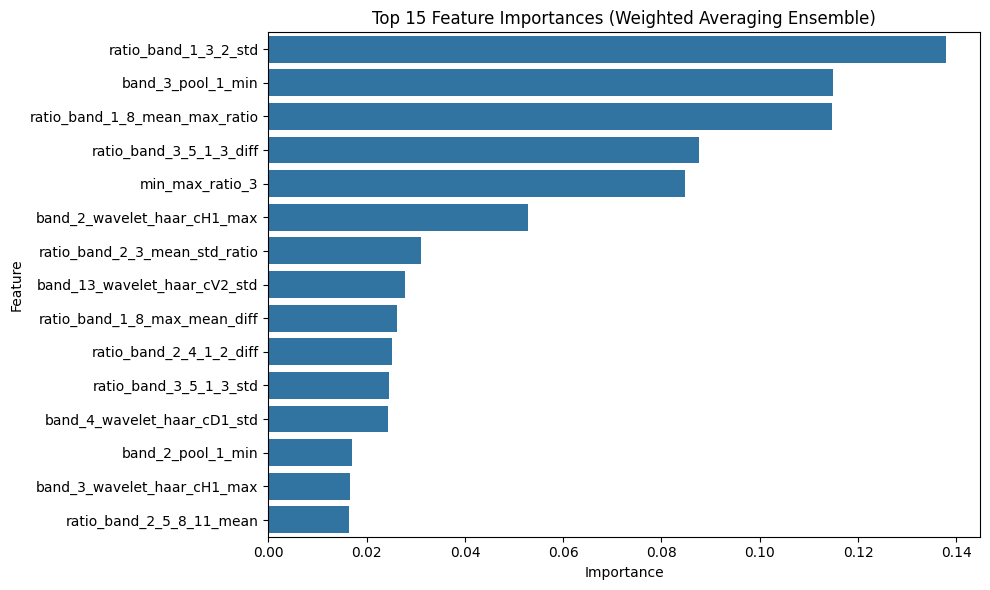

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(15), x='Importance', y='Feature')
plt.title("Top 15 Feature Importances (Weighted Averaging Ensemble)")
plt.tight_layout()
plt.show()

In [72]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import PartialDependenceDisplay
from scipy.stats import pearsonr

In [74]:
# Re-import if needed
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Define models with same parameters you used for final weighted ensemble
xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=8, random_state=42)
lightgbm_model = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.1, max_depth=8, random_state=42)

# Fit them to the full training set
xgb_model.fit(X, y)
lightgbm_model.fit(X, y)

# Combine feature importances from all three models
cat_importance = np.array(catboost_model.feature_importances_, dtype='float64')
xgb_importance = np.array(xgb_model.feature_importances_, dtype='float64')
lgb_importance = np.array(lightgbm_model.feature_importances_, dtype='float64')

# Normalize
cat_importance /= cat_importance.sum()
xgb_importance /= xgb_importance.sum()
lgb_importance /= lgb_importance.sum()

# Weighted average
ensemble_importance = 0.11 * cat_importance + 0.80 * xgb_importance + 0.09 * lgb_importance

# Create DataFrame
ensemble_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': ensemble_importance
}).sort_values(by='Importance', ascending=False)

# Top 10 Features
top_10_features = ensemble_importance_df.head(10)['Feature'].tolist()
X_top10 = pd.DataFrame(X, columns=feature_names)[top_10_features]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000698 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9180
[LightGBM] [Info] Number of data points in the train set: 4465, number of used features: 36
[LightGBM] [Info] Start training from score 0.209845
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

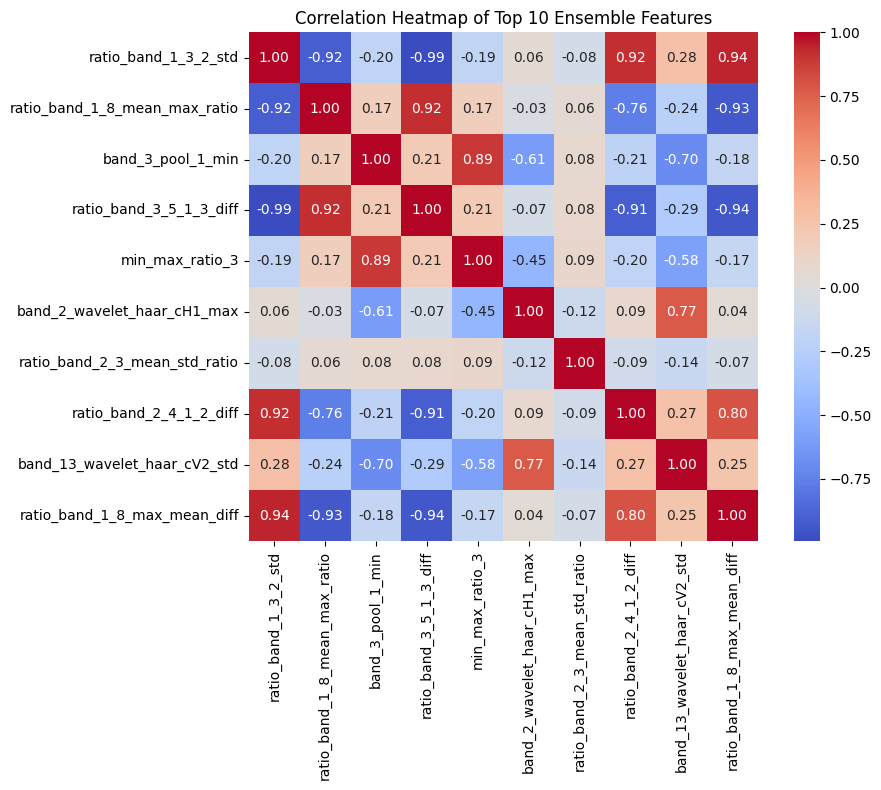

In [75]:
# Plot heatmap
plt.figure(figsize=(10, 8))
corr_top10 = X_top10.corr()
sns.heatmap(corr_top10, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap of Top 10 Ensemble Features")
plt.tight_layout()
plt.show()

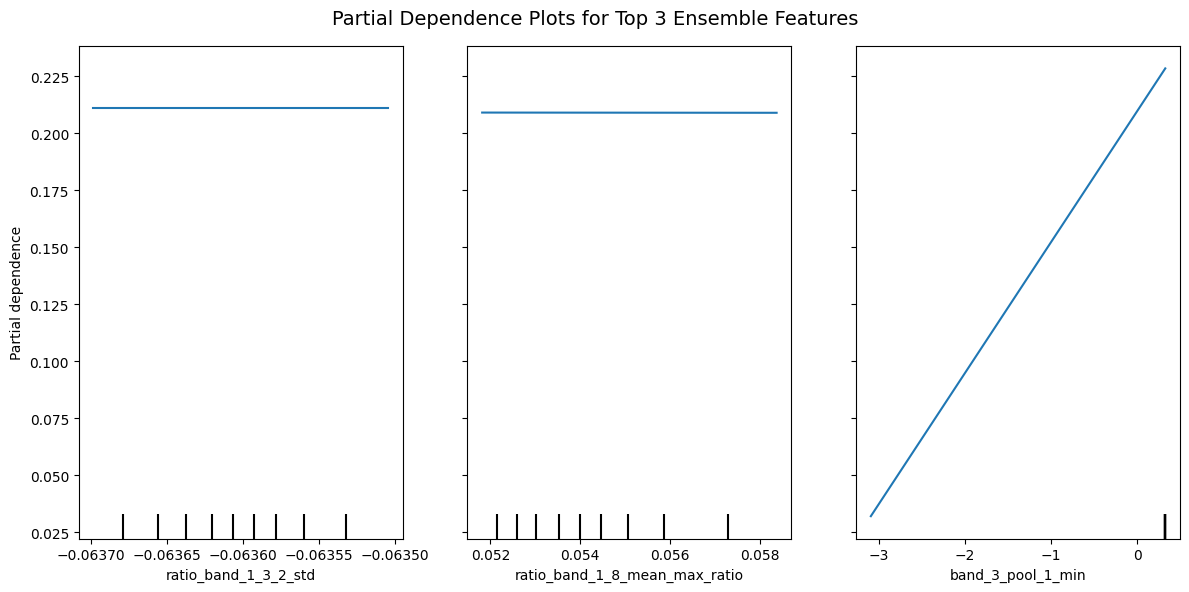

In [76]:
from sklearn.inspection import PartialDependenceDisplay

# Use scaled data and top 3 features
top3 = top_10_features[:3]
X_top10_scaled = StandardScaler().fit_transform(X_top10)

# Fit Ridge to X_top10
ridge_model = Ridge()
ridge_model.fit(X_top10_scaled, y)

# PDP
fig, ax = plt.subplots(figsize=(12, 6))
PartialDependenceDisplay.from_estimator(
    ridge_model, X_top10_scaled, top3, feature_names=top_10_features, ax=ax
)
plt.suptitle("Partial Dependence Plots for Top 3 Ensemble Features", fontsize=14)
plt.tight_layout()
plt.show()

In [87]:
from sklearn.base import BaseEstimator, RegressorMixin
import numpy as np

class WeightedEnsembleRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, models=None, weights=None):
        self.models = models
        self.weights = weights
    
    def fit(self, X, y):
        self.fitted_models_ = []
        for model in self.models:
            if hasattr(model, 'fit'):
                fitted = model.fit(X, y)
                self.fitted_models_.append(fitted)
            else:
                self.fitted_models_.append(model)
        self._is_fitted = True
        return self

    def predict(self, X):
        if not hasattr(self, "fitted_models_"):
            raise NotFittedError("This WeightedEnsembleRegressor instance is not fitted yet.")
        
        preds = np.column_stack([
            model.predict(X) for model in self.fitted_models_
        ])
        return np.average(preds, axis=1, weights=self.weights)

In [96]:
models = [catboost_model, xgb_model, lightgbm_model]
weights = [0.11, 0.8, 0.09]

import pandas as pd
from sklearn.preprocessing import StandardScaler

X_train_df = pd.DataFrame(X_train, columns=feature_names)

scaler_full = StandardScaler()
X_train_scaled = scaler_full.fit_transform(X_train_df)

ensemble_model = WeightedEnsembleRegressor(models=models, weights=weights)
ensemble_model.fit(X_train_scaled, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000776 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9180
[LightGBM] [Info] Number of data points in the train set: 4203, number of used features: 36
[LightGBM] [Info] Start training from score 0.208488
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

WeightedEnsembleRegressor(models=[<catboost.core.CatBoostRegressor object at 0x7656dafcf730>,
                                  XGBRegressor(base_score=None, booster=None,
                                               callbacks=None,
                                               colsample_bylevel=None,
                                               colsample_bynode=None,
                                               colsample_bytree=None,
                                               device=None,
                                               early_stopping_rounds=None,
                                               enable_categorical=False,
                                               eval_metric=None,
                                               feature_types=None, gamma=None,
                                               grow_policy=None,
                                               importan...
                                               learning_rate=0.1, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None, max_depth=8,
                                               max_leaves=None,
                                               min_child_weight=None,
                                               missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=200, n_jobs=None,
                                               num_parallel_tree=None,
                                               random_state=42, ...),
                                  LGBMRegressor(max_depth=8, n_estimators=200,
                                                random_state=42)],
                          weights=[0.11, 0.8, 0.09])

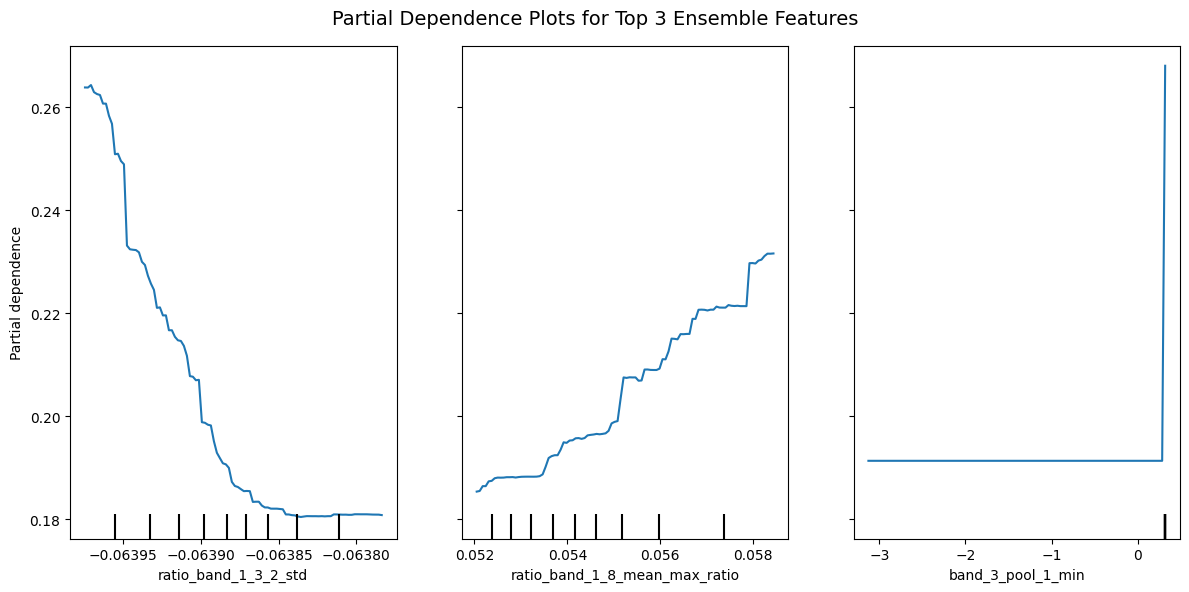

In [101]:
feature_names_list = list(feature_names)

top_3_indices = [feature_names_list.index(f) for f in top_3_features]

import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(12, 6))

PartialDependenceDisplay.from_estimator(
    ensemble_model,
    X_train_scaled,               
    features=top_3_indices,       
    feature_names=feature_names_list,
    kind="average",
    grid_resolution=100,
    ax=ax
)

plt.suptitle("Partial Dependence Plots for Top 3 Ensemble Features", fontsize=14)
plt.tight_layout()
plt.show()

<Axes: xlabel='band_3_pool_1_min', ylabel='Count'>

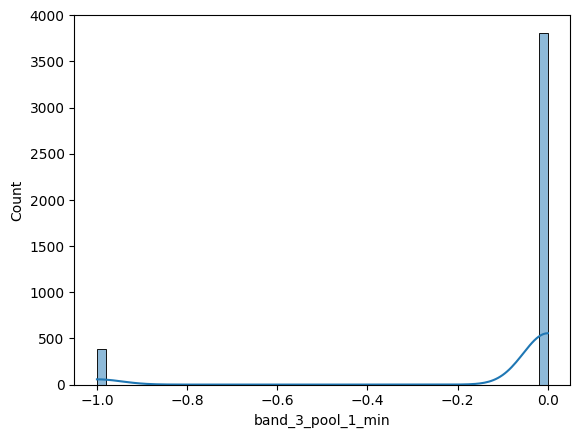

In [102]:
import seaborn as sns
sns.histplot(X_train_df['band_3_pool_1_min'], bins=50, kde=True)

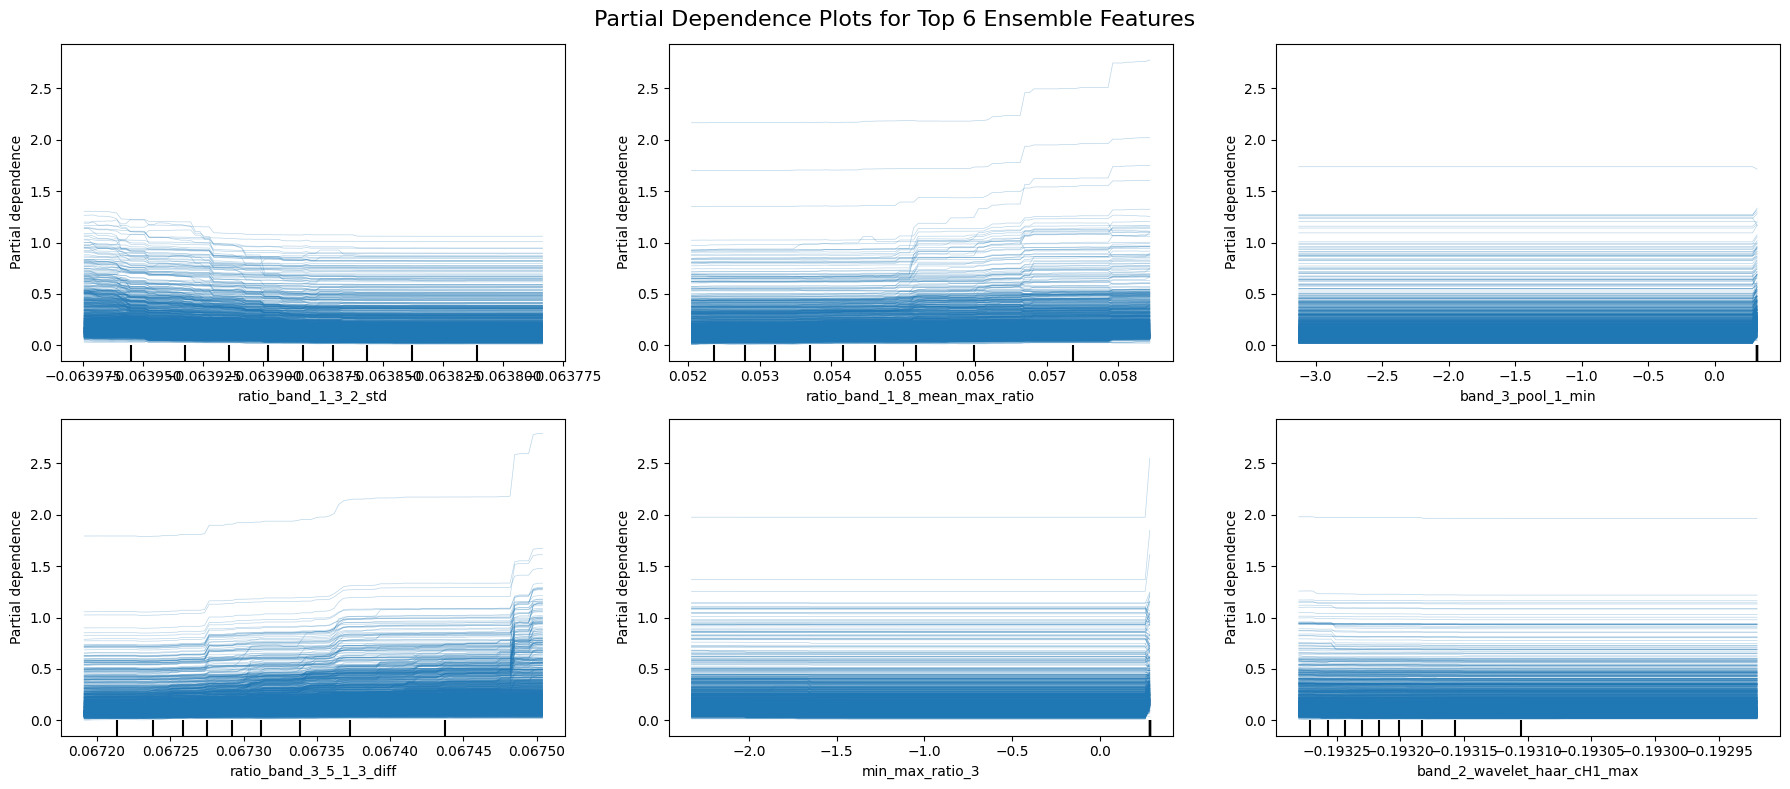

In [105]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

top_n = 6
top_n_features = top_10_features[:top_n]
top_n_indices = [list(feature_names).index(f) for f in top_n_features]

# Scale the full feature set for PDP
X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_train_scaled = scaler_full.transform(X_train_df)

# Plot PDPs
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(18, 8))
ax = ax.flatten()

PartialDependenceDisplay.from_estimator(
    ensemble_model,
    X_train_scaled,
    features=top_n_indices,
    feature_names=feature_names,
    kind="individual",
    grid_resolution=100,
    ax=ax
)

plt.suptitle(f"Partial Dependence Plots for Top {top_n} Ensemble Features", fontsize=16)
plt.tight_layout()
plt.show()

In [107]:
import shap
import matplotlib.pyplot as plt

model_for_shap = xgb_model

X_df = pd.DataFrame(X_train, columns=feature_names)

explainer = shap.TreeExplainer(model_for_shap)

# Compute SHAP interaction values
shap_interaction_values = explainer.shap_interaction_values(X_df)


<Figure size 640x480 with 0 Axes>

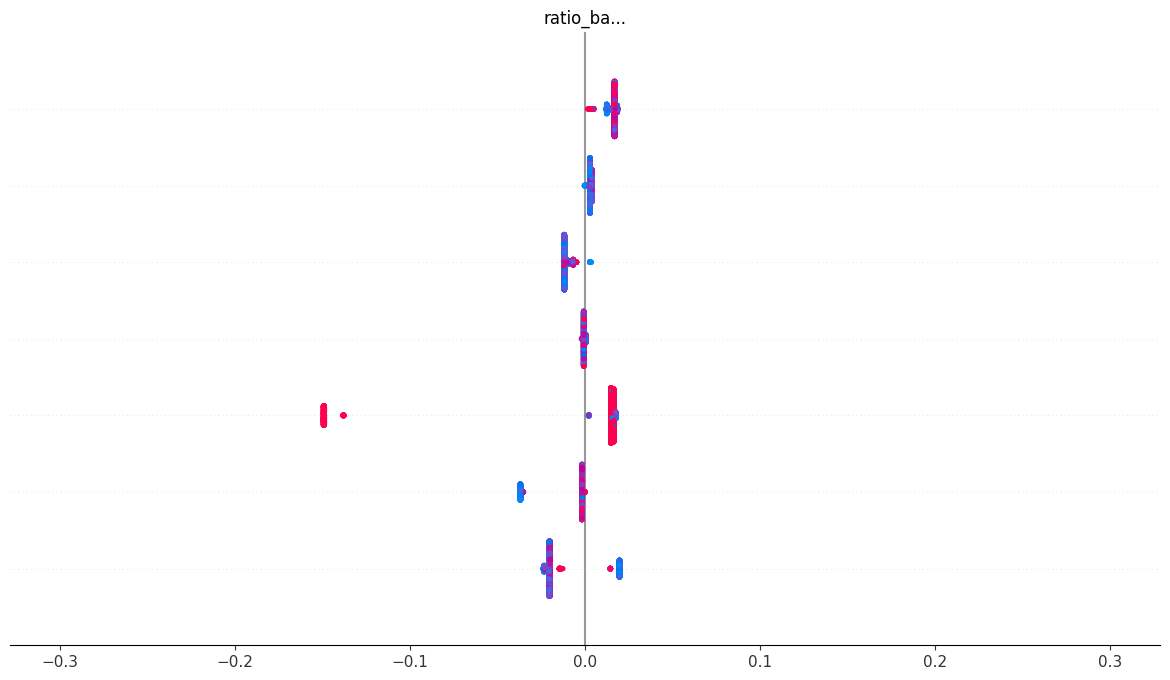

In [108]:
# SHAP Interaction Summary Plot
shap.summary_plot(shap_interaction_values, X_df)

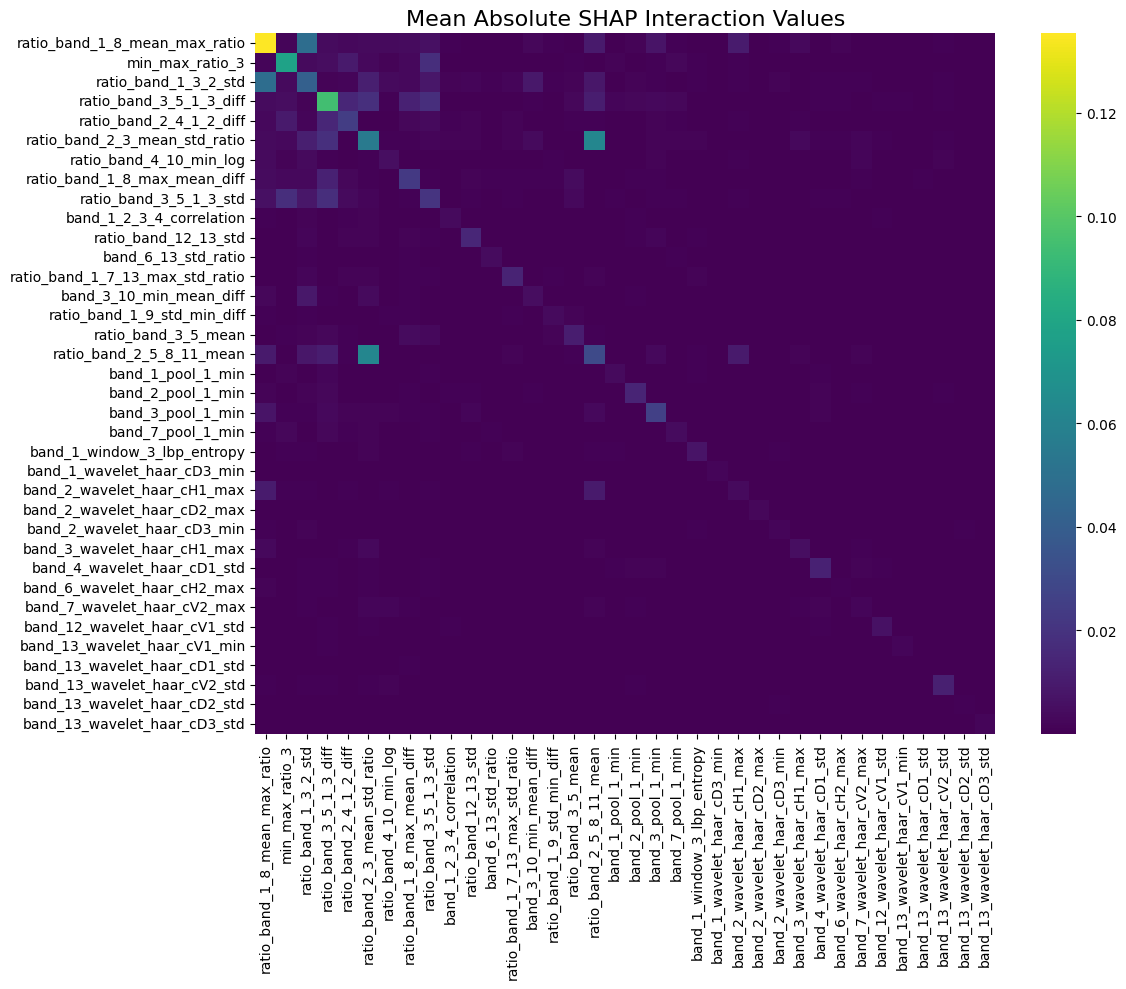

In [110]:
import shap
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

interaction_matrix = np.abs(shap_interaction_values).mean(axis=0)

# Create a DataFrame for the heatmap
interaction_df = pd.DataFrame(interaction_matrix, index=feature_names, columns=feature_names)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(interaction_df, cmap="viridis", xticklabels=True, yticklabels=True)
plt.title("Mean Absolute SHAP Interaction Values", fontsize=16)
plt.tight_layout()
plt.show()

In [111]:
# Get upper triangle of the interaction matrix without the diagonal
interaction_df_upper = interaction_df.where(np.triu(np.ones(interaction_df.shape), k=1).astype(bool))

# Unstack and sort the pairs
top_interactions = interaction_df_upper.unstack().dropna().sort_values(ascending=False)

# Display top N interactions
top_interactions.head(10)

ratio_band_2_5_8_11_mean       ratio_band_2_3_mean_std_ratio    0.062335
ratio_band_1_3_2_std           ratio_band_1_8_mean_max_ratio    0.047881
ratio_band_2_3_mean_std_ratio  ratio_band_3_5_1_3_diff          0.018047
ratio_band_3_5_1_3_std         min_max_ratio_3                  0.017563
                               ratio_band_3_5_1_3_diff          0.017454
ratio_band_2_4_1_2_diff        ratio_band_3_5_1_3_diff          0.014302
ratio_band_1_8_max_mean_diff   ratio_band_3_5_1_3_diff          0.012287
ratio_band_2_3_mean_std_ratio  ratio_band_1_3_2_std             0.011558
ratio_band_2_5_8_11_mean       ratio_band_3_5_1_3_diff          0.010605
band_2_wavelet_haar_cH1_max    ratio_band_1_8_mean_max_ratio    0.009785
dtype: float32

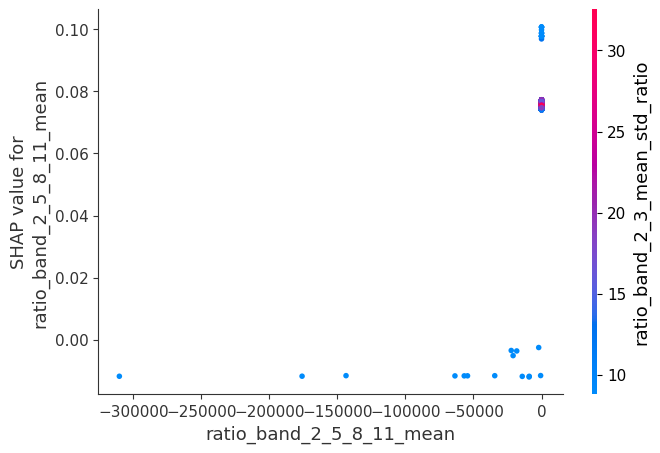

In [113]:
shap_values = explainer.shap_values(X_df)

shap.dependence_plot(
    "ratio_band_2_5_8_11_mean",    
    shap_values,                  
    X_df,                         
    interaction_index="ratio_band_2_3_mean_std_ratio"
)

In [122]:
import os
import pandas as pd

y_pred = ensemble_model.predict(X_test_scaled)

test_image_folder = "/home/coeai/Desktop/MM/test_images"

image_filenames = sorted(os.listdir(test_image_folder))

assert len(image_filenames) == len(y_pred), "Mismatch between image files and predictions!"

prediction_df = pd.DataFrame({
    "Filename": image_filenames,
    "Predicted_AOD": y_pred
})

prediction_df.to_csv("final_ensemble_predictions.csv", index=False)